<a href="https://colab.research.google.com/github/ilincabaiasu/IB9AU/blob/main/Task_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Required Task 9

### Details

The "Date Drift" Amortization Audit: LLMs are notoriously bad at "calendar math"
(e.g., calculating interest when a payment falls on a leap year, a weekend, or an
irregular date). They will hallucinate a smooth "textbook" amortization table that ignores
these messy realities.
The Scenario: You are auditing a small business loan that has irregular payment
dates. The borrower claims the bank overcharged them interest.
- Loan Principal: $100,000
- Annual Rate: 12% (calculated daily: Balance * (0.12 / 365) * Days_Elapsed)
- Start Date: Jan 1, 2024 (Leap Year)
- Payment Log:

  * Jan 31: $5,000

  * Feb 29: $5,000 (Leap Day)

  * Mar 31: $5,000

Beware of the trap: A standard LLM prompt will assume 30 days per month or miss the
Leap Day (Feb 29), leading to a wrong ending balance.

| Parameter | Value |
|---|---|
| Principal | \$100,000 |
| Annual Rate | 12% |
| Daily Rate Formula | `Balance × (0.12 / 365) × Days_Elapsed` |
| Start Date | Jan 1, 2024 (leap year) |

What I found interesting?
- The 30/29/31 day distribution matters in finamce, especially when discussing interest which compounds over time
- The problem exposes a weakness in how LLMs reason

In [1]:
from datetime import date
import pandas as pd

# ── Loan parameters ──────────────────────────────────────────────
PRINCIPAL   = 100_000
ANNUAL_RATE = 0.12
DAILY_RATE  = ANNUAL_RATE / 365

# Payment log: (date, amount)
# The start date carries $0 — it anchors the first period
PAYMENTS = [
    (date(2024,  1,  1),     0),   # loan start
    (date(2024,  1, 31), 5_000),
    (date(2024,  2, 29), 5_000),   # ← Feb 29 exists in 2024 (leap year)
    (date(2024,  3, 31), 5_000),
]

print(f"Daily rate: {ANNUAL_RATE} / 365 = {DAILY_RATE:.8f}")
print(f"Payments scheduled on: {[str(p[0]) for p in PAYMENTS[1:]]}")

Daily rate: 0.12 / 365 = 0.00032877
Payments scheduled on: ['2024-01-31', '2024-02-29', '2024-03-31']


### Correct Calendar Dates

In [2]:
def build_amortization(principal, daily_rate, payments, force_days=None):
    """
    Build an amortization table.

    Args:
        principal:   Starting loan balance.
        daily_rate:  Daily interest rate (annual_rate / 365).
        payments:    List of (date, amount) tuples; first entry is the start date.
        force_days:  If set, override actual day count with this fixed value (naive model).

    Returns:
        pd.DataFrame with one row per payment period.
    """
    rows = []
    balance = principal
    prev_date = payments[0][0]

    for pmt_date, pmt_amount in payments[1:]:
        days = force_days if force_days else (pmt_date - prev_date).days
        interest      = balance * daily_rate * days
        principal_paid = pmt_amount - interest
        end_balance   = balance - principal_paid

        rows.append({
            "Period":          f"{prev_date.strftime('%b %d')} → {pmt_date.strftime('%b %d, %Y')}",
            "Days":            days,
            "Open Balance":    round(balance, 2),
            "Interest":        round(interest, 2),
            "Principal Paid":  round(principal_paid, 2),
            "Ending Balance":  round(end_balance, 2),
        })

        balance   = end_balance
        prev_date = pmt_date

    df = pd.DataFrame(rows)

    # Totals row
    totals = pd.DataFrame([{
        "Period":         "TOTAL",
        "Days":           df["Days"].sum(),
        "Open Balance":   "",
        "Interest":       round(df["Interest"].sum(), 2),
        "Principal Paid": round(df["Principal Paid"].sum(), 2),
        "Ending Balance": round(balance, 2),
    }])

    return pd.concat([df, totals], ignore_index=True)


correct_df = build_amortization(PRINCIPAL, DAILY_RATE, PAYMENTS)
correct_df

,Period,Days,Open Balance,Interest,Principal Paid,Ending Balance
0,"Jan 01 → Jan 31, 2024",30,100000.0,986.30,4013.70,95986.30
1,"Jan 31 → Feb 29, 2024",29,95986.3,915.16,4084.84,91901.46
2,"Feb 29 → Mar 31, 2024",31,91901.46,936.64,4063.36,87838.10
3,TOTAL,90,,2838.10,12161.90,87838.10


### "Naive" Model

In [3]:
naive_df = build_amortization(PRINCIPAL, DAILY_RATE, PAYMENTS, force_days=30)
naive_df

,Period,Days,Open Balance,Interest,Principal Paid,Ending Balance
0,"Jan 01 → Jan 31, 2024",30,100000.0,986.30,4013.70,95986.30
1,"Jan 31 → Feb 29, 2024",30,95986.3,946.71,4053.29,91933.02
2,"Feb 29 → Mar 31, 2024",30,91933.02,906.74,4093.26,87839.75
3,TOTAL,90,,2839.75,12160.25,87839.75


### Audit Comparison

In [4]:
# Extract payment rows only (drop totals row)
c = correct_df.iloc[:-1].copy()
n = naive_df.iloc[:-1].copy()

comparison = pd.DataFrame({
    "Period":             c["Period"].values,
    "Actual Days":        c["Days"].values,
    "Naive Days":         n["Days"].values,
    "Correct Interest":   c["Interest"].values,
    "Naive Interest":     n["Interest"].values,
    "Difference":         (n["Interest"] - c["Interest"]).round(2).values,
})

print(comparison.to_string(index=False))

correct_final = float(correct_df.iloc[-1]["Ending Balance"])
naive_final   = float(naive_df.iloc[-1]["Ending Balance"])
balance_diff  = naive_final - correct_final

print(f"\n{'─'*55}")
print(f"Correct ending balance : ${correct_final:>10,.2f}")
print(f"Naive ending balance   : ${naive_final:>10,.2f}")
print(f"Balance discrepancy    : ${balance_diff:>10,.2f}")
print()
if balance_diff > 0:
    print("Verdict: The naive model OVERSTATES the ending balance.")
    print("The bank would incorrectly charge more interest in Period 2")
    print("(leap day period), partially offset by undercharging in Period 3.")
else:
    print("Verdict: The naive model UNDERSTATES the ending balance.")

               Period  Actual Days  Naive Days  Correct Interest  Naive Interest  Difference
Jan 01 → Jan 31, 2024           30          30            986.30          986.30        0.00
Jan 31 → Feb 29, 2024           29          30            915.16          946.71       31.55
Feb 29 → Mar 31, 2024           31          30            936.64          906.74      -29.90

───────────────────────────────────────────────────────
Correct ending balance : $ 87,838.10
Naive ending balance   : $ 87,839.75
Balance discrepancy    : $      1.65

Verdict: The naive model OVERSTATES the ending balance.
The bank would incorrectly charge more interest in Period 2
(leap day period), partially offset by undercharging in Period 3.


### Visualisation - Interest per Period

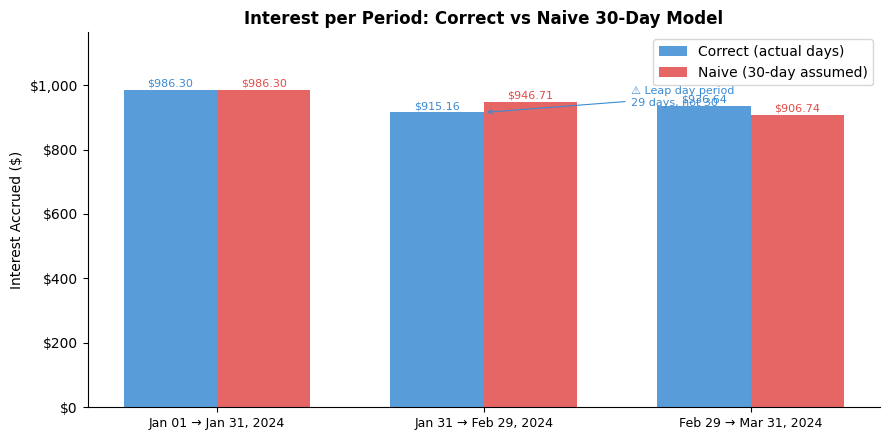

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

periods    = c["Period"].tolist()
correct_i  = c["Interest"].astype(float).tolist()
naive_i    = n["Interest"].astype(float).tolist()
x          = np.arange(len(periods))
width      = 0.35

fig, ax = plt.subplots(figsize=(9, 4.5))
bars1 = ax.bar(x - width/2, correct_i, width, label="Correct (actual days)",  color="#3B8BD4", alpha=0.85)
bars2 = ax.bar(x + width/2, naive_i,   width, label="Naive (30-day assumed)", color="#E24B4A", alpha=0.85)

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            f"${bar.get_height():,.2f}", ha="center", va="bottom", fontsize=8, color="#3B8BD4")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            f"${bar.get_height():,.2f}", ha="center", va="bottom", fontsize=8, color="#E24B4A")

ax.set_xticks(x)
ax.set_xticklabels(periods, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.set_ylabel("Interest Accrued ($)")
ax.set_title("Interest per Period: Correct vs Naive 30-Day Model", fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, max(max(correct_i), max(naive_i)) * 1.18)

# Annotate the leap-day period
ax.annotate("⚠ Leap day period\n29 days, not 30",
            xy=(1, correct_i[1]), xytext=(1.55, correct_i[1] + 20),
            fontsize=8, color="#3B8BD4",
            arrowprops=dict(arrowstyle="->", color="#3B8BD4", lw=0.8))

plt.tight_layout()
plt.show()

### Conclusion:

| Period | Actual days | Naive assumes | Effect on interest |
|---|---|---|---|
| Jan 1 → Jan 31 | 30 | 30 | No difference |
| Jan 31 → Feb 29 | **29** | 30 | Naive **overcharges** by ~\$31 |
| Feb 29 → Mar 31 | **31** | 30 | Naive **undercharges** by ~\$30 |

=> net balance discrepancy of ~\$1.65.